In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import streamlit as st
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
import warnings
import joblib
warnings.filterwarnings('ignore')

In [36]:
df=pd.read_csv("C:/Users/farah/Desktop/projet modelisation/dataase.csv")
df.head()

,date,crude oil ( WTI),Heating Oil,Conventional Gasoline,RBOB,Ultra-Low Sulfur CARB Diesel,Kerosene-Type Jet Fuel,Propane,Natural GAZ,DJIA,NASDAQ,sp500,bitcoin,USD FUTURE INDEX,gold,Silver,copper
0,2015-01-02,52.72,1.554,1.378,1.586,1.537,1.539,0.546,2.889,"17,501.65","4,726.81","2,058.20","8,726.2",99.596,"1,184.80",15.829,2.9295
1,2015-01-05,50.05,1.646,1.462,1.667,1.518,1.647,0.547,2.894,"17,371.64","4,652.57","2,020.60","8,916.8",99.768,"1,188.15",15.636,2.9205
2,2015-01-06,47.98,1.709,1.540,1.750,1.516,1.709,0.574,2.855,"17,584.52","4,592.74","2,002.60","8,547.4",98.940,"1,184.20",16.394,2.9350
3,2015-01-07,48.69,1.774,1.575,1.663,1.599,1.653,0.594,2.777,"17,907.87","4,650.47","2,025.90","8,473.2",98.525,"1,193.50",16.591,2.9260
4,2015-01-08,48.80,1.718,1.483,1.659,1.674,1.675,0.604,2.816,"17,737.37","4,736.19","2,062.10","8,143.5",97.614,"1,215.73",16.702,2.9180


In [37]:
df['date']=pd.to_datetime(df['date'])

In [38]:
numeric_columns=['DJIA','NASDAQ','sp500','bitcoin','gold','Silver']
for col in numeric_columns:
    if df[col].dtype=='object':
        df[col]=df[col].str.replace(',', '').astype(float)

In [39]:
df.set_index('date',inplace=True)

In [40]:
df.isnull().sum()

crude oil ( WTI)                64
Heating Oil                      0
Conventional Gasoline            0
 RBOB                            1
Ultra-Low Sulfur CARB Diesel     5
Kerosene-Type Jet Fuel           1
Propane                          7
Natural GAZ                     53
DJIA                            53
NASDAQ                          53
sp500                           53
bitcoin                         53
USD FUTURE INDEX                53
gold                            53
Silver                          53
 copper                         53
dtype: int64

In [41]:
df=df.fillna(method='ffill').fillna(method='bfill')

Raw CSV Data → Can't use directly in models
     
     ↓

Date Conversion → Enable time-based operations
    
     ↓

Numeric Conversion → Enable mathematical calculations
    
     ↓

Set Date Index → Optimize time series operations
     
     ↓

Handle Missing Values → Create complete, model-ready dataset
     
     ↓

Clean Data → Ready for modeling & analysis ✓

In [42]:
df.shape

(2569, 16)

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2569 entries, 2015-01-02 to 2024-12-31
Data columns (total 16 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   crude oil ( WTI)              2569 non-null   float64
 1   Heating Oil                   2569 non-null   float64
 2   Conventional Gasoline         2569 non-null   float64
 3    RBOB                         2569 non-null   float64
 4   Ultra-Low Sulfur CARB Diesel  2569 non-null   float64
 5   Kerosene-Type Jet Fuel        2569 non-null   float64
 6   Propane                       2569 non-null   float64
 7   Natural GAZ                   2569 non-null   float64
 8   DJIA                          2569 non-null   float64
 9   NASDAQ                        2569 non-null   float64
 10  sp500                         2569 non-null   float64
 11  bitcoin                       2569 non-null   float64
 12  USD FUTURE INDEX              2569 non-null 

In [44]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.describe()

,crude oil ( WTI),Heating Oil,Conventional Gasoline,RBOB,Ultra-Low Sulfur CARB Diesel,Kerosene-Type Jet Fuel,Propane,Natural GAZ,DJIA,NASDAQ,sp500,bitcoin,USD FUTURE INDEX,gold,Silver,copper
count,2569.000000,2569.000000,2569.000000,2569.000000,2569.000000,2569.000000,2569.000000,2569.000000,2569.000000,2569.000000,2569.000000,2569.000000,2569.000000,2569.000000,2569.000000,2569.000000
mean,62.169673,2.010637,1.968033,2.139995,2.128714,1.967696,0.730002,3.205448,28010.777859,10049.902923,3408.229517,31106.349825,98.283997,1639.295815,20.498172,3.277549
std,18.375937,0.731783,0.601646,0.678960,0.714588,0.707988,0.256444,1.412546,7532.339427,4291.209749,1131.156886,25371.452385,5.070437,415.384540,4.976831,0.785326
min,-36.980000,0.562000,0.434000,0.293000,0.566000,0.407000,0.203000,1.544000,15660.180000,4266.840000,1829.100000,3228.700000,88.505000,1051.740000,11.772000,1.943500
25%,48.490000,1.496000,1.543000,1.678000,1.620000,1.466000,0.514000,2.474000,21467.140000,6283.020000,2439.100000,9160.000000,94.618000,1274.760000,16.407000,2.636000
50%,59.930000,1.898000,1.905000,2.089000,2.036000,1.877000,0.700000,2.827000,26835.510000,8705.170000,3053.200000,24699.700000,97.301000,1646.520000,18.600000,3.089500
75%,74.310000,2.319000,2.315000,2.487000,2.440000,2.278000,0.886000,3.275000,34053.940000,13597.970000,4274.510000,46395.700000,102.127000,1897.870000,24.232000,4.026000
max,123.640000,5.152000,4.509000,4.968000,4.719000,5.066000,1.615000,9.647000,45014.040000,20173.890000,6090.270000,106157.200000,114.047000,2786.190000,35.041000,5.106000


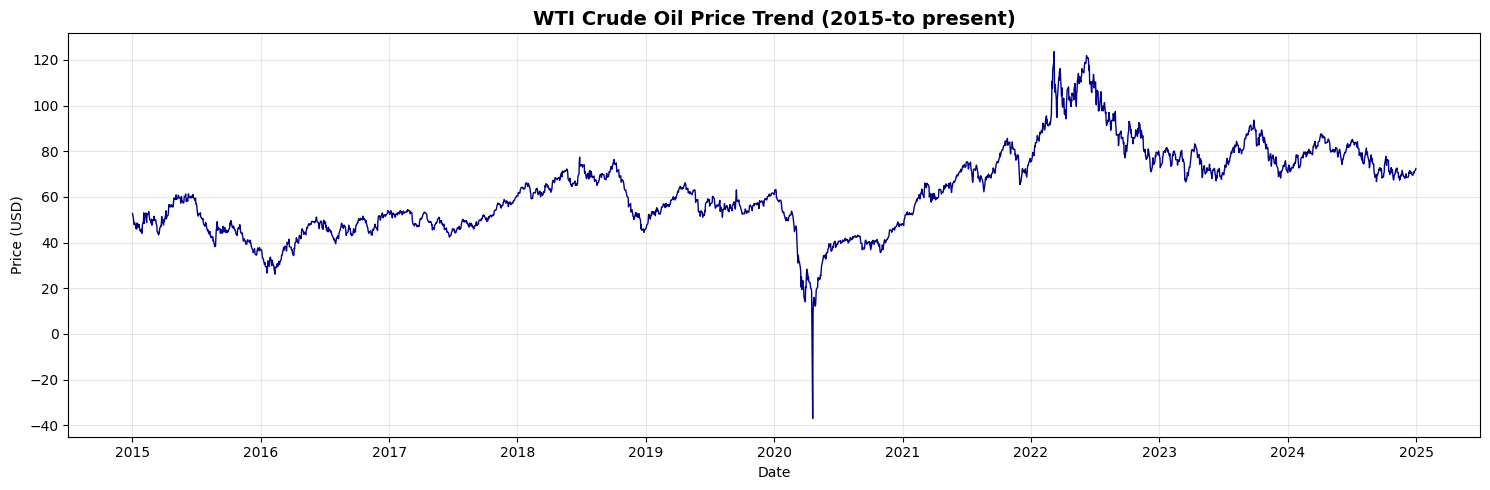

In [46]:
plt.figure(figsize=(15,5))
plt.plot(df.index,df['crude oil ( WTI)'],linewidth=1,color='darkblue')
plt.title('WTI Crude Oil Price Trend (2015-to present)',fontsize=14,fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.grid(True, alpha=0.3)
plt.tight_layout()

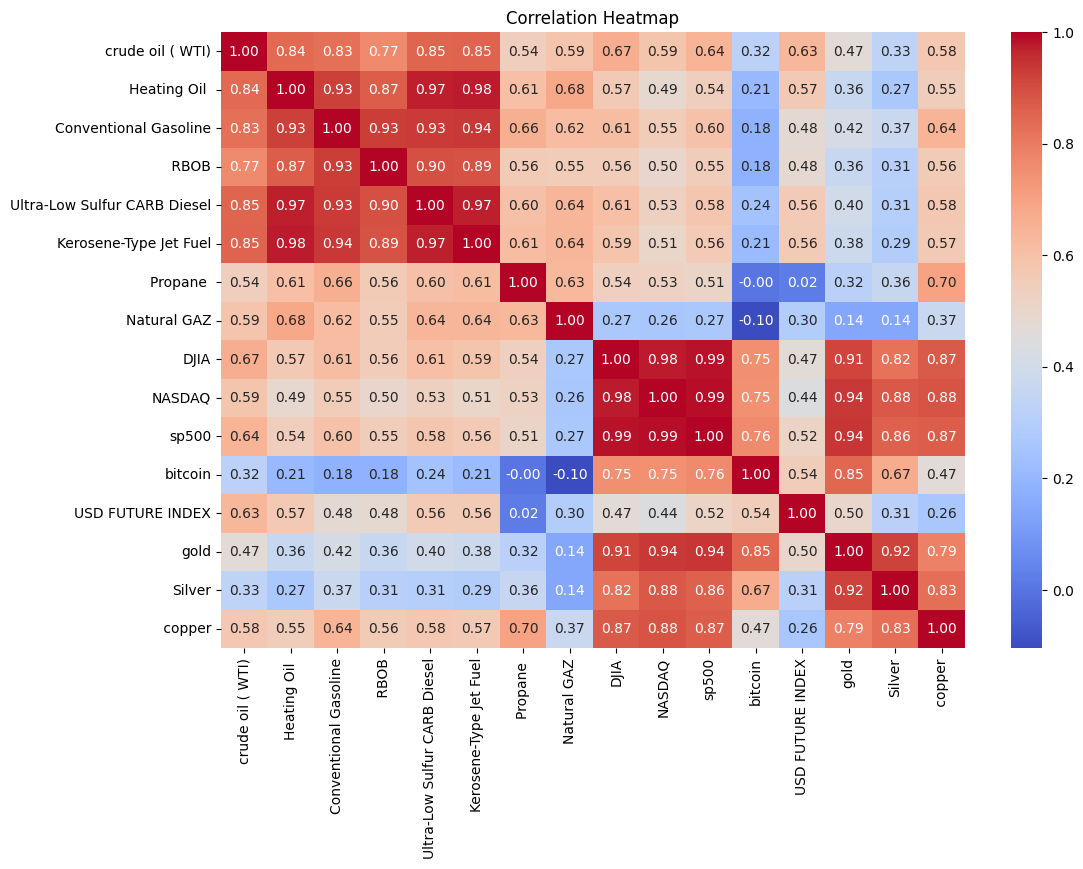


Top 10 features correlated with WTI:
crude oil ( WTI)                1.000000
Kerosene-Type Jet Fuel          0.854161
Ultra-Low Sulfur CARB Diesel    0.853086
Heating Oil                     0.842406
Conventional Gasoline           0.826539
 RBOB                           0.765543
DJIA                            0.666130
sp500                           0.644383
USD FUTURE INDEX                0.634691
Natural GAZ                     0.588960
Name: crude oil ( WTI), dtype: float64


In [47]:
correlation_matrix = df.corr()
wti_correlations=correlation_matrix['crude oil ( WTI)'].sort_values(ascending=False)
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Heatmap")
plt.show()
print("\nTop 10 features correlated with WTI:")
print(wti_correlations.head(10))

## feature engineering:

In [48]:
df_features=df.copy()
target_col='crude oil ( WTI)'

In [49]:
#lehne el lag features houma el past values used as inputs to predict the future eli houa el price. lehne el wti_lag_{1} maaneha price el bereh
#wti_lag_{3} maaneha price 3 yem lteli w hekadha
#Lag features only use past data to predict future
for lag in [1,3,5,7]:
    df_features[f'wti_lag_{lag}']=df_features[target_col].shift(lag)

Why useful?

- Oil prices are autocorrelated → Today's price depends on yesterday's
- Captures momentum: If oil was $80 yesterday, unlikely to be $50 today
- Different lags capture different patterns:
- lag_1 → Short-term momentum
- lag_7 → Weekly trends
- lag_30 → Monthly trends

In [50]:
#lehne calculates the average price over the last window days, maaneha wti_rolling_mean_7->Average price over last 7 days (1 week)
#el Rolling Std ykhalina naarfou about el Volatility/Stability
#el  Rolling Mean ykhalina ndetectiw Trends,
for window in [7,14,30]:
    df_features[f'wti_rolling_mean_{window}']=df_features[target_col].rolling(window=window).mean()
    df_features[f'wti_rolling_std_{window}']=df_features[target_col].rolling(window=window).std()

Why useful?

-  Smooths noise: Daily fluctuations vs real trends
- Trading signals: When short MA crosses long MA → trend change
- Volatility: High volatility = risky period, affects prices
- Support/Resistance: Min/Max show price boundaries

In [51]:
df_features['wti_price_change']=df_features[target_col].pct_change()

In [52]:
df_features=df_features.dropna()

In [53]:
df_features.shape

(2540, 27)

In [54]:
df_features.shape[1]

27

In [55]:
X=df_features.drop(columns=[target_col])
y=df_features[target_col]

"""
X = Everything EXCEPT the oil price (your input features)
y = ONLY the oil price (what you want to predict)
"""

'\nX = Everything EXCEPT the oil price (your input features)\ny = ONLY the oil price (what you want to predict)\n'

In [56]:
# Filter features with correlation > 0.5
X=df_features.drop(columns=[target_col])
y=df_features[target_col]

# Calculate correlations between features and target
correlations = X.corrwith(y).abs()
selected_features = correlations[correlations > 0.5].index.tolist()

print(f"Features with correlation > 0.5 with {target_col}:")
print(correlations[correlations > 0.5].sort_values(ascending=False))
print(f"\nTotal features selected: {len(selected_features)} out of {X.shape[1]}")

# Keep only selected features
X = X[selected_features]

Features with correlation > 0.5 with crude oil ( WTI):
wti_lag_1                       0.993324
wti_rolling_mean_7              0.992058
wti_lag_3                       0.985753
wti_rolling_mean_14             0.985085
wti_lag_5                       0.979235
wti_lag_7                       0.973085
wti_rolling_mean_30             0.967857
Kerosene-Type Jet Fuel          0.854952
Ultra-Low Sulfur CARB Diesel    0.854134
Heating Oil                     0.843634
Conventional Gasoline           0.826023
 RBOB                           0.767379
DJIA                            0.663671
sp500                           0.641459
USD FUTURE INDEX                0.634569
Natural GAZ                     0.588756
NASDAQ                          0.581455
 copper                         0.573530
Propane                         0.538180
dtype: float64

Total features selected: 19 out of 26


- Reduces Overfitting
- Overfitting = Model memorizes training data but fails on new data

Too many features → Model learns noise → Poor predictions

Fewer, strong features → Model learns patterns → Good predictions

In [57]:
split_index=int(len(X)*0.8)
X_train,X_test=X[:split_index],X[split_index:]
y_train,y_test=y[:split_index],y[split_index:]

In [58]:
print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"Train date range: {X_train.index.min()} to {X_train.index.max()}")
print(f"Test date range: {X_test.index.min()} to {X_test.index.max()}")

Training set: 2032 samples
Test set: 508 samples
Train date range: 2015-02-13 00:00:00 to 2023-01-10 00:00:00
Test date range: 2023-01-11 00:00:00 to 2024-12-31 00:00:00


In [59]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)
"""StandardScaler transforms each feature to have:
Mean = 0
Standard Deviation = 1
"""

'StandardScaler transforms each feature to have:\nMean = 0\nStandard Deviation = 1\n'

# Calculate R² on BOTH sets
train_pred=best_model.predict(X_train_scaled)
test_pred=best_model.predict(X_test_scaled)

train_r2=r2_score(y_train, train_pred)
test_r2=r2_score(y_test, test_pred)

print(f"Training R²: {train_r2:.4f}")
print(f"Test R²:     {test_r2:.4f}")
print(f"Difference:  {abs(train_r2 - test_r2):.4f}")

joblib.dump(scaler,'wti_scaler.pkl')
print("Scaler saved")

In [60]:
models={}
predictions={}

In [61]:
#1. linear regression
lr=LinearRegression()
lr.fit(X_train_scaled,y_train)
models['Linear Regression']=lr
predictions['Linear Regression']=lr.predict(X_test_scaled)
print("Linear Regression trained")

#2. Random Forest Regressor
rf=RandomForestRegressor(n_estimators=100,max_depth=15,random_state=42,n_jobs=-1)
rf.fit(X_train_scaled,y_train)
models['Random Forest']=rf
predictions['Random Forest']=rf.predict(X_test_scaled)
print("Random Forest trained")

#3. XGBoost Regressor
xgb_model=xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train_scaled,y_train)
models['XGBoost']=xgb_model
predictions['XGBoost']=xgb_model.predict(X_test_scaled)
print(" XGBoost trained")

#4. Gradient Boosting Regressor
gb=GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)
gb.fit(X_train_scaled, y_train)
models['Gradient Boosting']=gb
predictions['Gradient Boosting']=gb.predict(X_test_scaled)
print("Gradient Boosting trained")

#5. Support Vector Regressor
svr_model=SVR(kernel='linear',C=100,gamma='auto',epsilon=0.1)
svr_model.fit(X_train_scaled, y_train)
models['SVR']=svr_model
predictions['SVR']=svr_model.predict(X_test_scaled)
print("SVR trained")

Linear Regression trained
Random Forest trained
 XGBoost trained
Gradient Boosting trained
SVR trained


In [62]:
def calculate_mape(y_true, y_pred):
    return np.mean(np.abs((y_true-y_pred)/y_true))*100
results=[]
for model_name,y_pred in predictions.items():
    rmse=np.sqrt(mean_squared_error(y_test, y_pred))
    mae=mean_absolute_error(y_test,y_pred)
    mape=calculate_mape(y_test.values,y_pred)
    r2=r2_score(y_test,y_pred)
    
    results.append({
        'Model': model_name,
        'RMSE': rmse,
        'MAE': mae,
        'MAPE (%)': mape,
        'R² Score': r2
    })
    

In [63]:
results_df=pd.DataFrame(results)
results_df=results_df.sort_values('RMSE')

print("\n"+"="*50)
print("MODEL PERFORMANCE COMPARISON")
print("="*50)
print(results_df.to_string(index=False))
print("="*50)

best_model_name=results_df.iloc[0]['Model']
best_model=models[best_model_name]
print(f"\nBest Model:{best_model_name}")
print(f"   RMSE:{results_df.iloc[0]['RMSE']:.2f}")
print(f"   R² Score:{results_df.iloc[0]['R² Score']:.4f}")


MODEL PERFORMANCE COMPARISON
            Model     RMSE      MAE  MAPE (%)  R² Score
              SVR 1.175054 0.928255  1.216001  0.958570
Linear Regression 1.234577 0.979904  1.279026  0.954266
    Random Forest 1.533823 1.231574  1.603321  0.929409
Gradient Boosting 1.778313 1.448092  1.874288  0.905111
          XGBoost 1.868921 1.493299  1.922795  0.895195

Best Model:SVR
   RMSE:1.18
   R² Score:0.9586


#### Model Ranking Explained:

- 1st Place: SVR (Support Vector Regressor) ⭐
Why it won: Uses support vectors (key data points) to find optimal decision boundary
Strength: Excellent at finding non-linear relationships with filtered features
Error: Only $1.18 off on average!
R² Score: 0.9586 (95.86% accuracy)

- 2nd Place: Linear Regression
Why it's solid: Simple but effective with highly correlated features (0.5+)
Error: $1.23 - still good!
R² Score: 0.9543 (95.43% accuracy)

- 3rd Place: Random Forest
Why it's decent: Ensemble of decision trees
Error: $1.53 - acceptable
R² Score: 0.9294 (92.94% accuracy)

- 4th Place: Gradient Boosting
Why it's weaker: May overfit on training data with smaller feature set
Error: $1.78 - less precise
R² Score: 0.9051 (90.51% accuracy)

- 5th Place: XGBoost
Why it underperformed: Similar overfitting issues as Gradient Boosting
Error: $1.87 - least accurate
R² Score: 0.8952 (89.52% accuracy)
*****************************************************************************************************************
#### Key Insight:
After filtering to only features with correlation > 0.5:
- SVR's performance IMPROVED significantly
- Tree-based models showed slight degradation
- Feature filtering removed noise that benefited linear/SVR models

#### SVR Wins Because:
- Support vectors capture essential data patterns effectively
- Works well with highly correlated feature set (19 selected features)
- Less prone to overfitting with reduced feature space
- Linear kernel with optimized C parameter (C=100) provides excellent precision
*****************************************************************************************************************
#### R² Score Interpretation:
- SVR: 0.9586 (95.86% of WTI price variance explained)
- Linear Regression: 0.9543 (95.43% explained)
- All models have strong positive R² (> 0.89) - all are reliable!

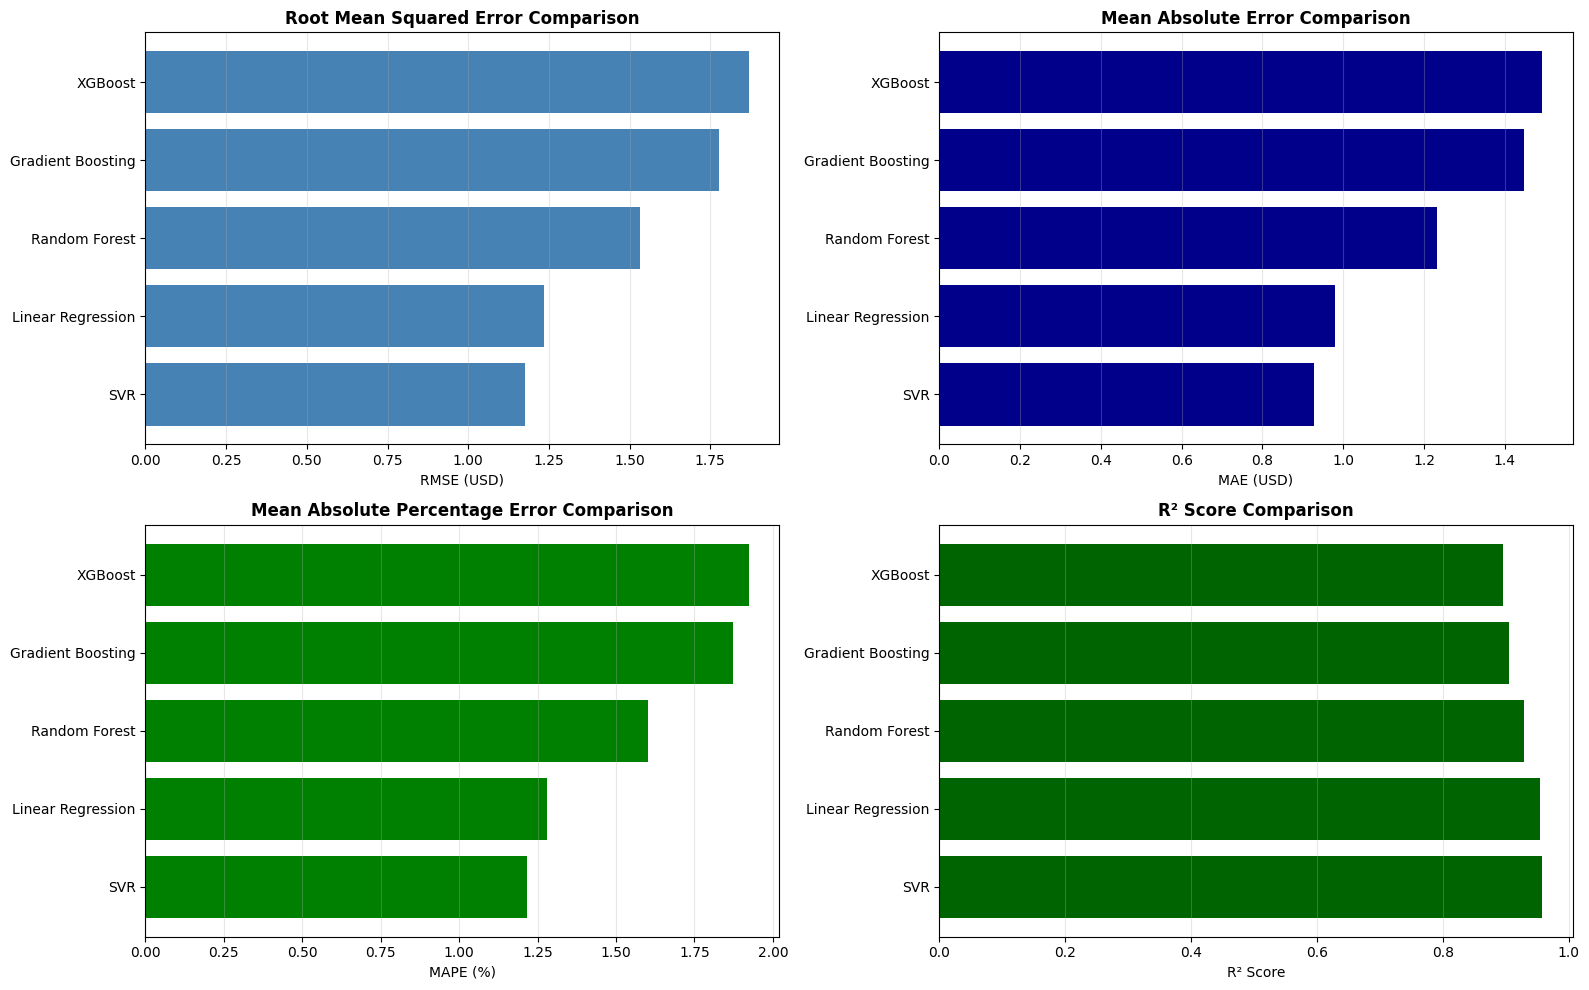

In [64]:
fig,axes=plt.subplots(2,2,figsize=(16,10))

# RMSE comparison:
axes[0,0].barh(results_df['Model'],results_df['RMSE'],color='steelblue')
axes[0,0].set_xlabel('RMSE (USD)')
axes[0,0].set_title('Root Mean Squared Error Comparison',fontweight='bold')
axes[0,0].grid(axis='x',alpha=0.3)

# MAE comparison
axes[0,1].barh(results_df['Model'],results_df['MAE'],color='darkblue')
axes[0,1].set_xlabel('MAE (USD)')
axes[0,1].set_title('Mean Absolute Error Comparison',fontweight='bold')
axes[0,1].grid(axis='x',alpha=0.3)

# MAPE comparison
axes[1,0].barh(results_df['Model'],results_df['MAPE (%)'],color='green')
axes[1,0].set_xlabel('MAPE (%)')
axes[1,0].set_title('Mean Absolute Percentage Error Comparison',fontweight='bold')
axes[1,0].grid(axis='x',alpha=0.3)

# R² Score comparison
axes[1,1].barh(results_df['Model'],results_df['R² Score'],color='darkgreen')
axes[1,1].set_xlabel('R² Score')
axes[1,1].set_title('R² Score Comparison',fontweight='bold')
axes[1,1].grid(axis='x',alpha=0.3)

plt.tight_layout()

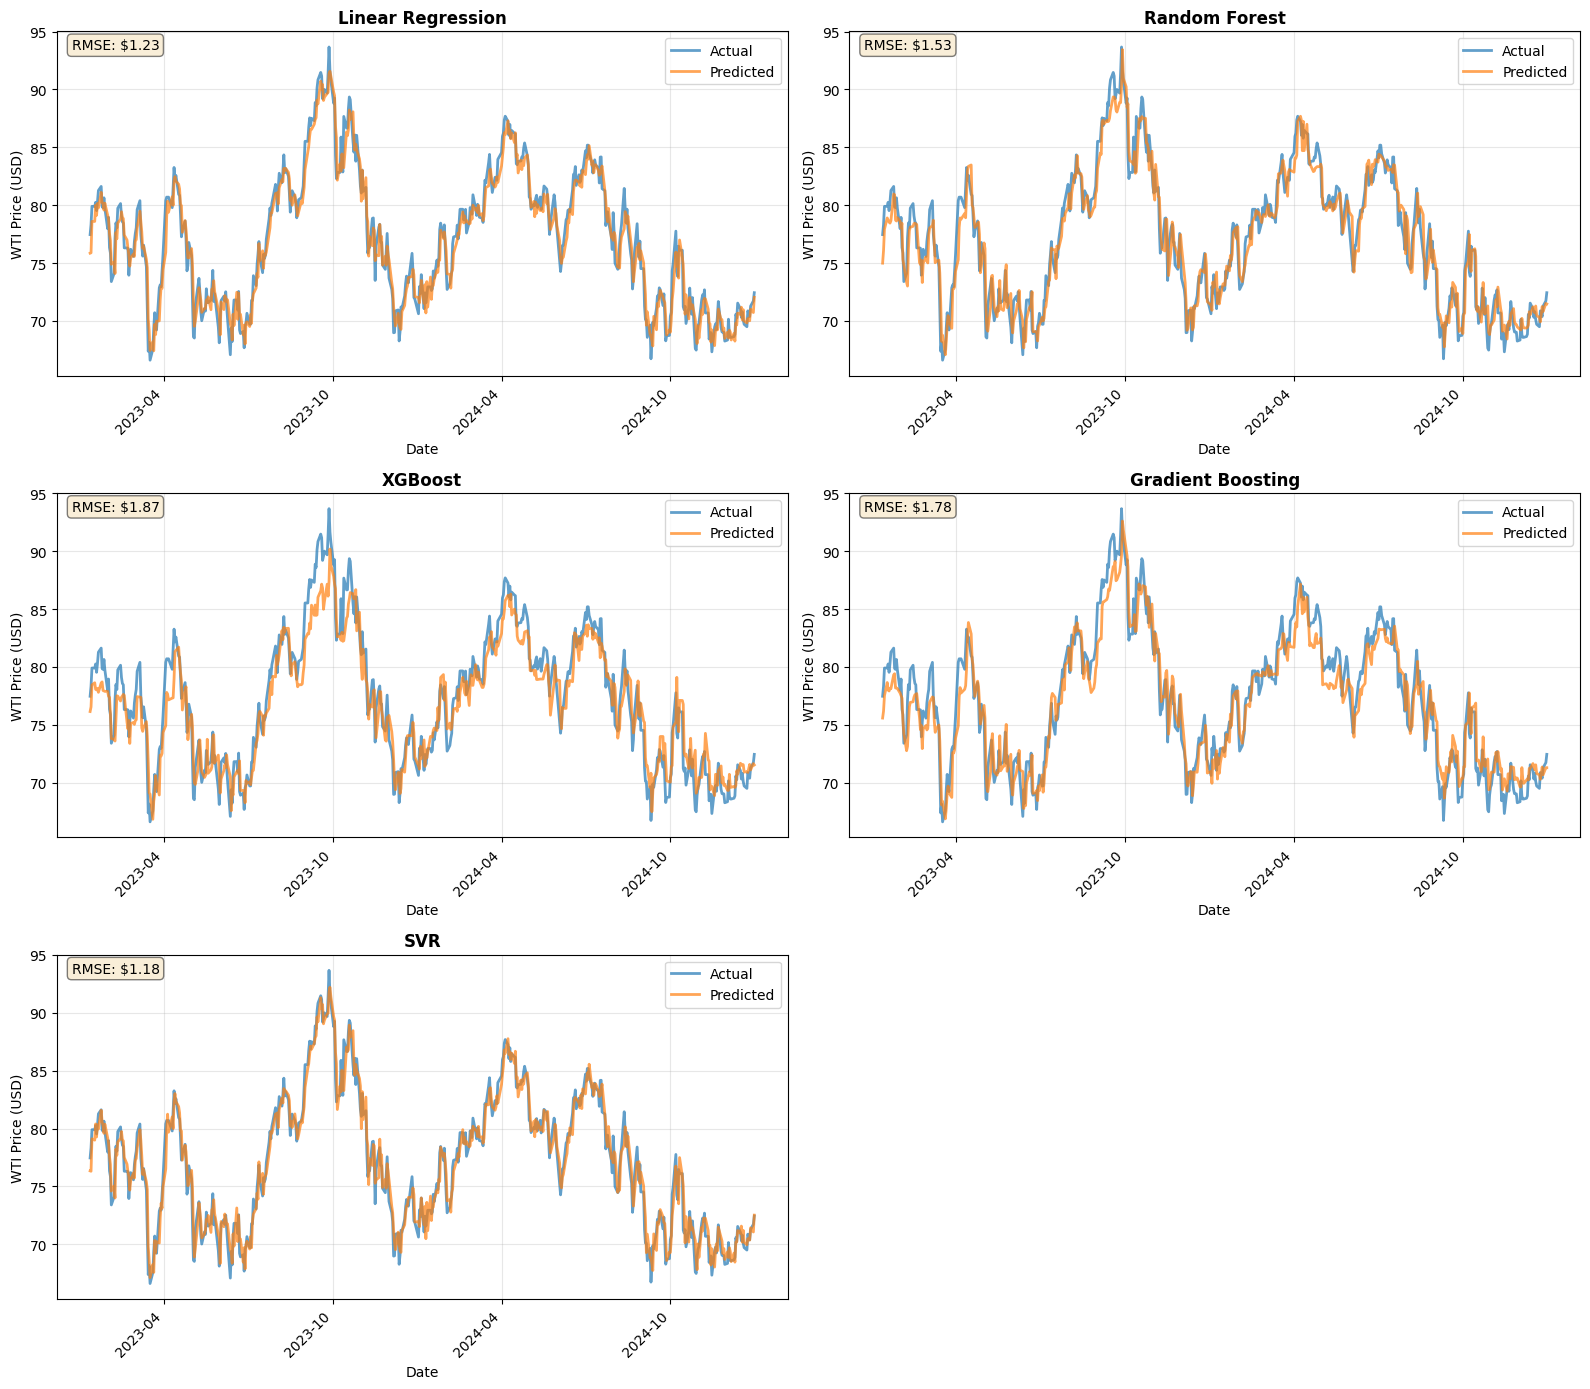

In [65]:
#Actual vs Predicted for all models
import matplotlib.dates as mdates 
fig,axes=plt.subplots(3,2,figsize=(16,14))
axes=axes.flatten()

for idx,(model_name, y_pred) in enumerate(predictions.items()):
    axes[idx].plot(y_test.index, y_test.values, label='Actual', linewidth=2, alpha=0.7)
    axes[idx].plot(y_test.index, y_pred, label='Predicted', linewidth=2, alpha=0.7)
    axes[idx].set_title(f'{model_name}', fontweight='bold')
    axes[idx].set_xlabel('Date')
    axes[idx].set_ylabel('WTI Price (USD)')
    # Format dates properly
    axes[idx].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    axes[idx].xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    plt.setp(axes[idx].xaxis.get_majorticklabels(), rotation=45, ha='right')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)
    
    # Add RMSE to the plot
    rmse=np.sqrt(mean_squared_error(y_test, y_pred))
    axes[idx].text(0.02,0.98,f'RMSE: ${rmse:.2f}', 
                   transform=axes[idx].transAxes, 
                   verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
axes[-1].remove()
plt.tight_layout()

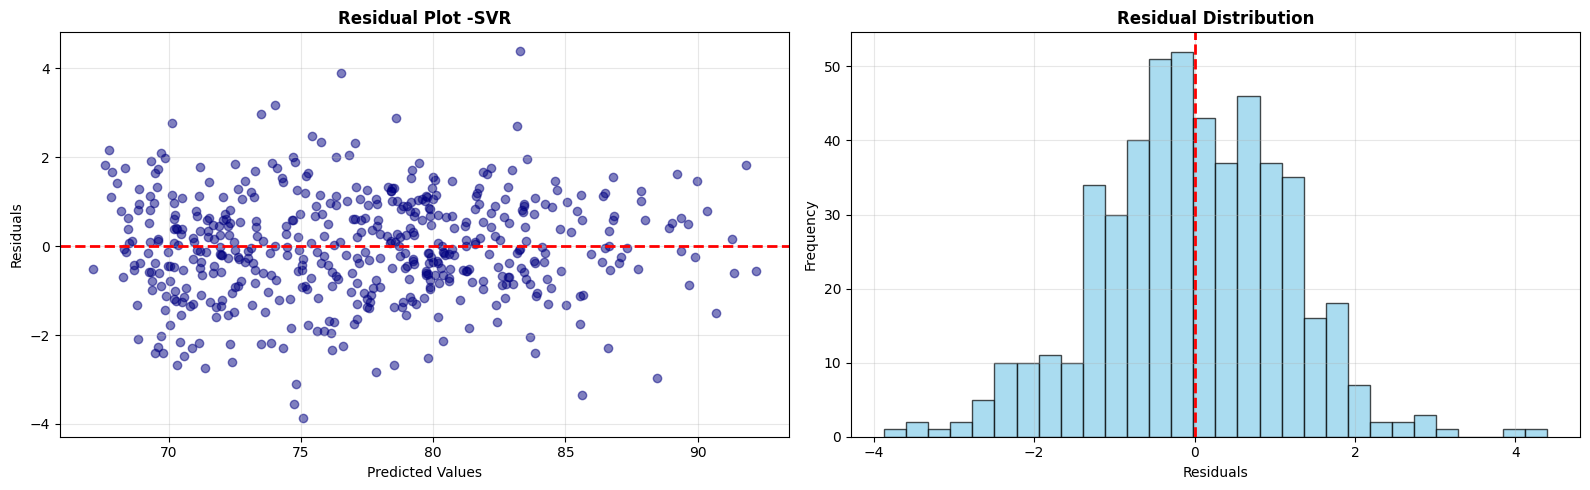

In [66]:
#Residual Analysis for Best Model
best_pred=predictions[best_model_name]
residuals=y_test.values-best_pred

fig,axes=plt.subplots(1,2,figsize=(16,5))

# Residual plot
axes[0].scatter(best_pred,residuals,alpha=0.5,color='navy')
axes[0].axhline(y=0, color='red',linestyle='--',linewidth=2)
axes[0].set_xlabel('Predicted Values')
axes[0].set_ylabel('Residuals')
axes[0].set_title(f'Residual Plot -{best_model_name}',fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Residual distribution
axes[1].hist(residuals,bins=30,color='skyblue',edgecolor='black',alpha=0.7)
axes[1].axvline(x=0,color='red',linestyle='--',linewidth=2)
axes[1].set_xlabel('Residuals')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residual Distribution',fontweight='bold')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()

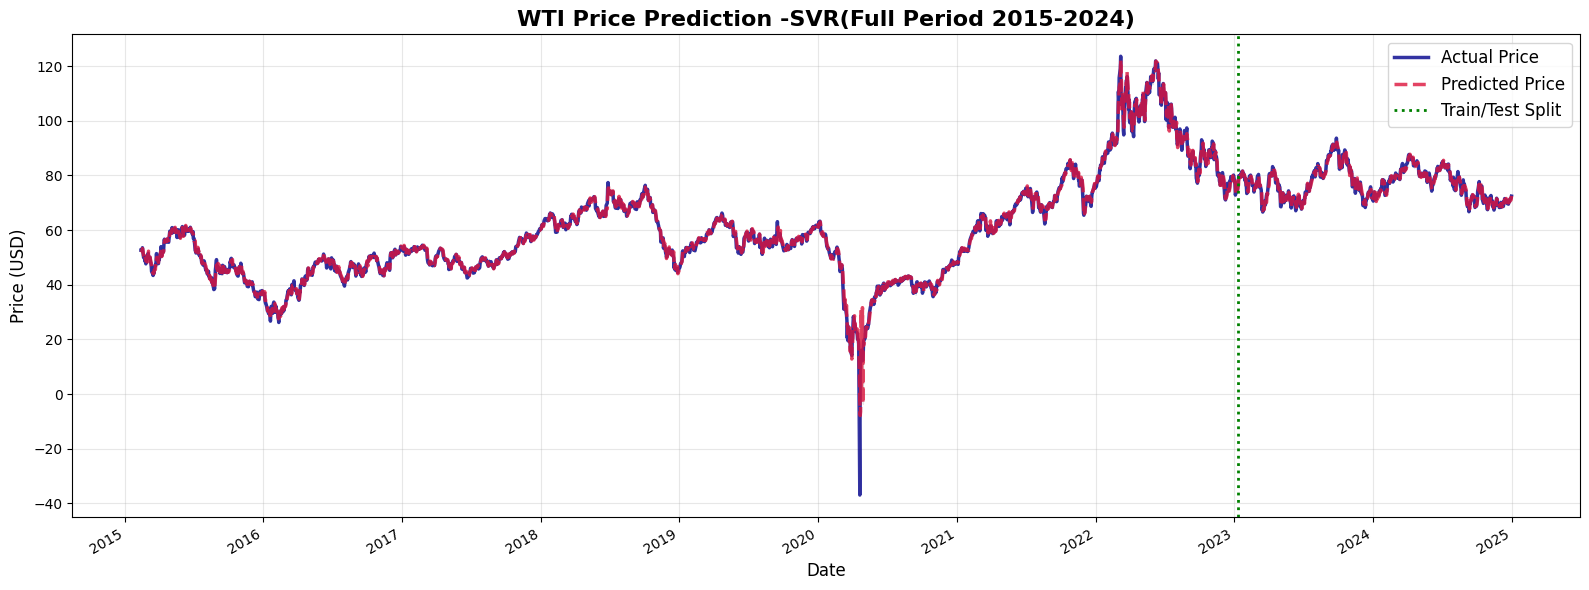

In [67]:
#Best Model d Prediction Plot
plt.figure(figsize=(16, 6))

# Get predictions for BOTH train and test
train_pred=best_model.predict(X_train_scaled)
test_pred=best_model.predict(X_test_scaled)

# Combine train and test predictions
all_actual=pd.concat([y_train,y_test])
all_pred=np.concatenate([train_pred,test_pred])

# Plot full period
plt.plot(all_actual.index, all_actual.values, label='Actual Price', 
         linewidth=2.5, color='darkblue', alpha=0.8)
plt.plot(all_actual.index, all_pred, label='Predicted Price', 
         linewidth=2.5, color='crimson', alpha=0.8, linestyle='--')
plt.fill_between(all_actual.index, all_actual.values, all_pred, alpha=0.2, color='gray')

# Add vertical line to show train/test split
plt.axvline(x=y_test.index[0],color='green',linestyle=':',linewidth=2, 
            label='Train/Test Split')

plt.title(f'WTI Price Prediction -{best_model_name}(Full Period 2015-2024)', 
          fontsize=16, fontweight='bold')
plt.xlabel('Date',fontsize=12)
plt.ylabel('Price (USD)',fontsize=12)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gcf().autofmt_xdate()
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [68]:
import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
import warnings

warnings.filterwarnings('ignore')

# Set page config
st.markdown(
    """
    <div style='background-color: #CECECE; padding: 0px; text-align: center; font-size: 32px; font-weight: bold; color: #E53A3C;'>
        WTI Crude Oil Price Prediction
    </div>
    """,
    unsafe_allow_html=True
)

# --- Helper Functions ---

@st.cache_data
def load_data():
    try:
        df = pd.read_csv('dataase.csv')
    except FileNotFoundError:
        try:
            df = pd.read_excel('dataase.xlsx')
        except FileNotFoundError:
            return None
    
    if 'date' in df.columns:
        df['date'] = pd.to_datetime(df['date'])
        df.set_index('date', inplace=True)
    
    numeric_columns = ['DJIA', 'NASDAQ', 'sp500', 'bitcoin', 'gold', 'Silver']
    for col in numeric_columns:
        if col in df.columns and df[col].dtype == 'object':
            df[col] = df[col].str.replace(',', '').astype(float)
            
    df = df.fillna(method='ffill').fillna(method='bfill')
    return df

def add_features(df_input, target_col='crude oil ( WTI)'):
    df_features = df_input.copy()
    
    # Lag features
    for lag in [1, 3, 5, 7]:
        df_features[f'wti_lag_{lag}'] = df_features[target_col].shift(lag)
    
    # Rolling features
    for window in [7, 14, 30]:
        df_features[f'wti_rolling_mean_{window}'] = df_features[target_col].rolling(window=window).mean()
        df_features[f'wti_rolling_std_{window}'] = df_features[target_col].rolling(window=window).std()
            
    df_features['wti_price_change'] = df_features[target_col].pct_change()
    return df_features

@st.cache_resource
def train_models(X_train, y_train, X_test, y_test):
    models = {}
    predictions = {}
    
    # 1. Linear Regression
    lr = LinearRegression()
    lr.fit(X_train, y_train)
    models['Linear Regression'] = lr
    predictions['Linear Regression'] = lr.predict(X_test)
    
    # 2. Random Forest
    rf = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    models['Random Forest'] = rf
    predictions['Random Forest'] = rf.predict(X_test)
    
    # 3. XGBoost
    xgb_model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42, n_jobs=-1)
    xgb_model.fit(X_train, y_train)
    models['XGBoost'] = xgb_model
    predictions['XGBoost'] = xgb_model.predict(X_test)
    
    # 4. Gradient Boosting
    gb = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
    gb.fit(X_train, y_train)
    models['Gradient Boosting'] = gb
    predictions['Gradient Boosting'] = gb.predict(X_test)
    
    # 5. SVR
    svr = SVR(kernel='rbf', C=100, gamma='auto', epsilon=0.1)
    svr.fit(X_train, y_train)
    models['SVR'] = svr
    predictions['SVR'] = svr.predict(X_test)
    
    return models, predictions

# --- Main App Logic ---

def main():
    st.sidebar.title("Navigation menu")
    page = st.sidebar.radio("", 
        ["Dataset Insights", 
         "Interactive Manual Prediction", 
         "Model Performance & Ranking",
         "Prediction Visualization",
         "Forecast Next 7 Days"]
    )
    st.sidebar.markdown("<br>" * 8, unsafe_allow_html=True)  

    st.sidebar.markdown(
    "<div style='text-align: center;'>Made by<br><b>Farah Belghith & Zaineb Darchem</b></div>",
    unsafe_allow_html=True
    )


    df = load_data()
    if df is None:
        st.error("Dataset not found. Please ensure 'dataase.csv' or 'dataase.xlsx' is in the app directory.")
        return

    target_col = 'crude oil ( WTI)'
    
    # Prepare data for models (Global context)
    df_processed = add_features(df, target_col).dropna()
    X = df_processed.drop(columns=[target_col])
    y = df_processed[target_col]
    
    split_index = int(len(X) * 0.8)
    X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
    y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    models, predictions = train_models(X_train_scaled, y_train, X_test_scaled, y_test)
    
    # Calculate Results Helper
    results = []
    for name, y_pred in predictions.items():
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        mae = mean_absolute_error(y_test, y_pred)
        mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
        r2 = r2_score(y_test, y_pred)
        results.append({'Model': name, 'RMSE': rmse, 'MAE': mae, 'MAPE (%)': mape, 'R2 Score': r2})
    results_df = pd.DataFrame(results).sort_values(by='RMSE').reset_index(drop=True)
    results_df.index = results_df.index + 1
    best_model_name = results_df.iloc[0]['Model']
    best_model = models[best_model_name]
    # --- Page 1: Dataset & Overview ---
    if page == "Dataset Insights":
        st.markdown("### Dataset Overview")
        st.markdown("The dataset contains historical daily data for various financial and energy indicators.")
        
        col1, col2 = st.columns(2)
        with col1:
            st.subheader("Data Preview")
            st.write(df.head(8))
        with col2:
            st.subheader("Descriptive Statistics")
            st.write(df.describe())

        st.markdown(f"**Target Column:** `{target_col}`")
        st.markdown("We chose West Texas Intermediate (WTI) Crude Oil price as the target variable because it is a key benchmark for oil pricing globally. It is also economically important, has sufficient data, and is easy to interpret.")

    # --- Page 2: Interactive Manual Prediction ---
    elif page == "Interactive Manual Prediction":
        st.header("Interactive Manual Prediction")
        st.markdown("""
        Adjust the sliders below to simulate market conditions and other features. 
        The model will instantly predict the WTI Crude Oil Price based on your inputs.
        """)
        
        # Create a placeholder for the price at the top
        price_placeholder = st.empty()

        # Get top 10 features
        feature_cols = X.columns.tolist()
        top_10_features = feature_cols[:10] 
        
        # Create input dictionary
        user_input = {}
        
        col1, col2 = st.columns(2)
        
        for i, feature in enumerate(top_10_features):
            # Determine min/max/mean for slider defaults
            min_val = float(X[feature].min())
            max_val = float(X[feature].max())
            mean_val = float(X[feature].mean())
            
            with col1 if i % 2 == 0 else col2:
                user_input[feature] = st.slider(
                    f"{feature}", 
                    min_value=min_val, 
                    max_value=max_val, 
                    value=mean_val,
                    key=f"slider_{feature}"
                )

        # Fill remaining features with mean values to complete the input vector
        for feature in feature_cols[10:]:
            user_input[feature] = X[feature].mean()
            
        # Calculate Prediction Instantly
        input_df = pd.DataFrame([user_input])
        input_scaled = scaler.transform(input_df)
        prediction = best_model.predict(input_scaled)[0]
        
        # Display at the top
        price_placeholder.markdown(
            f"""
            <div style="background-color: #e8e8e8; padding: 0px; border-radius: 10px; text-align: center; margin-bottom: 0px;">
                <h3 style="margin:0; color: #31333F;">Predicted WTI Price</h3>
                <h1 style="margin:0; color: #E53A3C; font-size: 3em;">${prediction:.2f}</h1>
            </div>
            """, 
            unsafe_allow_html=True
        )

    # --- Page 3: Model Performance ---
    elif page == "Model Performance & Ranking":
        st.header("Model Performance & Ranking")
        
        st.markdown("""
        ### About Tree-Based Models
        Tree-based models like **Random Forest**, **Gradient Boosting**, and **XGBoost** build decisions based on a series of rules (trees). 
        - **Random Forest** builds many independent trees and averages them.
        - **Gradient Boosting & XGBoost** build trees sequentially, where each new tree tries to fix the errors of the previous ones.
        These are often superior for tabular data as they capture non-linear complex relationships well.
        """)
        
        st.table(results_df.style.highlight_min(subset=['RMSE', 'MAE', 'MAPE (%)'], color='lightgreen').highlight_max(subset=['R2 Score'], color='lightgreen'))
        
        st.subheader("Model Interpretation")
        st.success(f"**Winner: {best_model_name}**")
        st.markdown(f"""
        The **{best_model_name}** model achieved the lowest RMSE.
        
        **Why Gradient Boosting/XGBoost perform well:**
        - They effectively handle complex, non-linear relationships.
        - Robust against noise in financial data.
        
        **Why SVR might perform worse:**
        - SVR can struggle with specific kernels on noisy multi-feature time-series data without extensive tuning.
        """)
        
    # --- Page 4: Prediction Visualization ---
    elif page == "Prediction Visualization":
        st.header("Actual vs Predicted Prices")
        st.markdown("Compare the actual market prices against the model's predictions.")
        
        selected_model_viz = st.selectbox("Select Model to Visualize", results_df['Model'].tolist())
        
        fig, ax = plt.subplots(figsize=(12, 6))
        ax.plot(y_test.index, y_test.values, label='Actual Price', color='black', linewidth=2)
        ax.plot(y_test.index, predictions[selected_model_viz], label=f'Predicted ({selected_model_viz})', color='red', linestyle='--', alpha=0.8)
        ax.set_title(f"Actual vs Predicted ({selected_model_viz})")
        ax.set_xlabel("Date")
        ax.set_ylabel("Price")
        ax.legend()
        ax.grid(True, alpha=0.3)
        st.pyplot(fig)

    # --- Page 5: Forecast Next 7 Days ---
    elif page == "Forecast Next 7 Days":
        st.header("Forecast Next 7 Days")
        st.markdown("This section uses the best performing model to forecast WTI prices for the next 7 days, based on the growing trend.")
        
        if st.button("Generate Forecast"):
            # Start with the very last available data point (including raw)
            # We need to simulate the future.
            # Strategy: Take the Full DF. Append 7 new rows with dates.
            # Forward fill exogenous variables (Naive assumption).
            # Iteratively calculate features and predict.
            
            future_days = 7
            last_date = df.index[-1]
            future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=future_days)
            
            # Create a working copy of the dataframe
            df_forecast = df.copy()
            
            predictions_future = []
            
            progress_bar = st.progress(0)
            
            for i, date in enumerate(future_dates):
                # 1. Append a new row with index = date
                # We use the previous row values for exogenous features (Simple Naive Forecast for inputs)
                last_row = df_forecast.iloc[-1].copy()
                # Set target to NaN effectively (or we can just leave it as last value temporarily, but we want to predict it)
                # Ideally, we don't know the target.
                
                new_row = pd.DataFrame([last_row], index=[date])
                # We interpret 'exogenous' columns as "staying same".
                
                df_forecast = pd.concat([df_forecast, new_row])
                
                # 2. Re-calculate features for this new extended dataframe
                # Note: This is inefficient (re-calcing whole history) but safe and easy for consistency.
                df_features_temp = add_features(df_forecast, target_col)
                
                # 3. Get the feature vector for the *last* row (the one we just added)
                # We need to drop the target col to get X
                last_row_features = df_features_temp.iloc[[-1]].drop(columns=[target_col])
                
                # 4. Scale
                last_row_scaled = scaler.transform(last_row_features)
                
                # 5. Predict
                pred_price = best_model.predict(last_row_scaled)[0]
                predictions_future.append(pred_price)
                
                # 6. Update the DataFrame's target column for this date with the predicted value
                # so that *next* iteration's lag features will use this prediction.
                df_forecast.at[date, target_col] = pred_price
                
                progress_bar.progress((i + 1) / future_days)
            
            # Plotting
            st.subheader("7-Day Forecast Results")
            forecast_df = pd.DataFrame({'Date': future_dates, 'Predicted Price': predictions_future})
            forecast_df.set_index('Date', inplace=True)
            
            st.table(forecast_df)
            
            # Download Button
            csv = forecast_df.to_csv().encode('utf-8')
            st.download_button(
                label="Download Forecast Results as CSV",
                data=csv,
                file_name='7_day_wti_forecast.csv',
                mime='text/csv',
            )
            
            fig_fc, ax_fc = plt.subplots(figsize=(10, 5))
            # Show last 30 days of actual history + 7 days forecast
            history_df = df.iloc[-30:][target_col]
            
            ax_fc.plot(history_df.index, history_df.values, label='Historical (Last 30 Days)', color='black')
            ax_fc.plot(forecast_df.index, forecast_df['Predicted Price'], label='Forecast (Next 7 Days)', color='green', marker='o', linestyle='--')
            
            ax_fc.set_title(f"7-Day Forecast with {best_model_name}")
            ax_fc.set_xlabel("Date")
            ax_fc.set_ylabel("Price (USD)")
            ax_fc.legend()
            ax_fc.grid(True, alpha=0.3)
            st.pyplot(fig_fc)

if __name__ == "__main__":
    main()

2025-12-13 15:51:12.411 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-13 15:51:13.379 
  command:

    streamlit run C:\Users\farah\AppData\Roaming\Python\Python310\site-packages\ipykernel_launcher.py [ARGUMENTS]
2025-12-13 15:51:13.379 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-13 15:51:13.381 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-13 15:51:13.381 No runtime found, using MemoryCacheStorageManager
2025-12-13 15:51:13.387 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-13 15:51:13.387 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-13 15:51:13.389 Thread 'MainThread': missing ScriptRunContext! This warn